# Seaborn Demos

## Sample

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

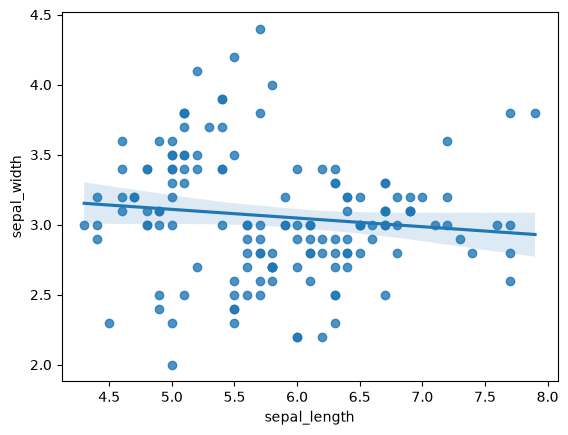

In [1]:
# library & dataset
import seaborn as sns
df = sns.load_dataset('iris')

# use the function regplot to make a scatterplot
sns.regplot(x=df["sepal_length"], y=df["sepal_width"])


## Demo

### Import seaborn as `sns`

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set()  # seaborn's method to set its chart style

### We use see seaborn for easy integration with the DataFrame from the Pandas

https://seaborn.pydata.org/examples/index.html

### See the different syntax (seaborn uses Matplotlib under the hood)

In [9]:
#### Ploting the joint distribution with matplotlib

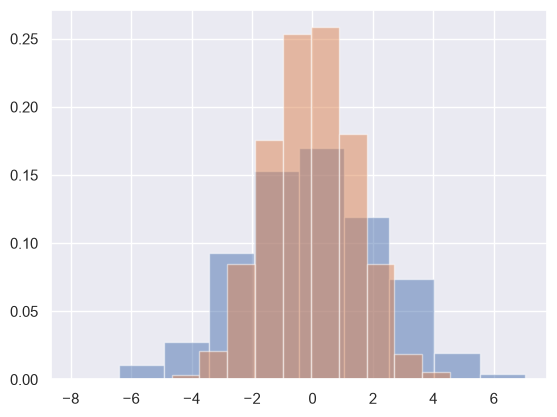

In [ ]:
# ============================================================================
# WHAT THIS LINE DOES (in plain English):
#
#   data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
#
# Think of it as a "random point generator" that creates 2000 fake data points.
# Each point has TWO numbers (like an X and a Y coordinate on a graph).
#
#   [0, 0]        --> The CENTER of the cloud of points (start around x=0, y=0)
#
#   [[5, 2],
#    [2, 2]]      --> How SPREAD OUT and how TILTED the cloud is:
#                      - 5 = points spread widely left-to-right (X direction)
#                      - 2 = points spread a bit up-and-down (Y direction)
#                      - 2 = the cloud is TILTED, so when X goes up, Y tends
#                            to go up too (they're linked / correlated)
#
#   size=2000     --> Make 2000 of these random points
#
#   data          --> A box holding all 2000 points, ready to plot or analyze
#
# In short: "Give me 2000 random (x, y) points scattered in a tilted blob
#            centered at the origin, following a bell-curve pattern."
# ============================================================================
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)





data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=["x", "y"])

for col in "xy":
    plt.hist(data[col], density=True, alpha=0.5)

#### Covariance explained

Think of the covariance matrix like a report card for two variables, say height and weight.

The **diagonal** numbers are each variable's own variance. That's how spread out each one is by itself. You already understand this part.

The **off-diagonal** numbers are the covariance. They answer one simple question: when one variable goes up, what does the other one tend to do?

- **Positive number** (like 2): both move together. When one goes up, the other goes up too. Example: height and weight.
- **Zero**: no relationship. They move independently.
- **Negative number** (like -2): they move opposite. When one goes up, the other goes down. Example: exercise and body fat.

So if you want the two variables to be linked, you pick a positive number. If you want them unrelated, you pick 0. If you want them opposite, you pick a negative number.

How big should that number be? A safe rule is to keep it **smaller than the diagonal variances**. A common formula is:

`cov = correlation × √(var1 × var2)`

Here `correlation` is a number between -1 and 1 that says how strong the link is (0 = none, 1 = perfect together, -1 = perfect opposite).

Example: if var1 = 5 and var2 = 2, and you want a fairly strong positive link (correlation around 0.63), then:

`cov = 0.63 × √(5 × 2) ≈ 2`

That gives you `[[5, 2], [2, 2]]`, the matrix from before.

Two last things to remember:

1. The matrix must be **symmetric**. The top-right number and the bottom-left number are always the same, because "X with Y" is the same as "Y with X".
2. If you pick off-diagonal numbers that are too large, the matrix becomes invalid and NumPy will give you an error.

In [5]:
data

,x,y
0,-0.913873,-0.675366
1,-4.146819,-1.286980
2,-3.445110,0.002337
3,0.257053,0.957254
4,0.977639,-0.101565
...,...,...
1995,0.851429,-0.938169
1996,3.101800,1.272978
1997,-0.399053,1.073939
1998,-0.639745,1.797302


### Density plot and contour plot

##### Density plot (`sns.kdeplot(data, fill)`)

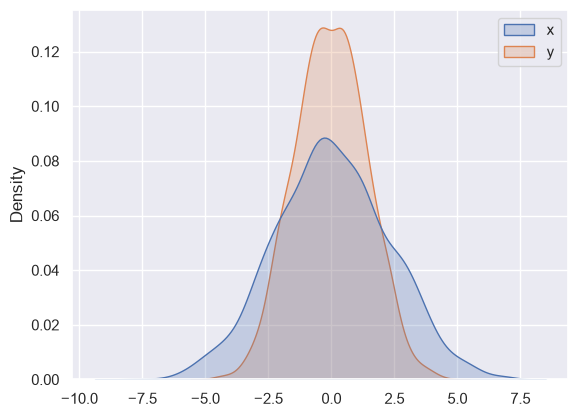

In [17]:
sns.kdeplot(data=data, fill=True);

##### Contour plot (`sns.kdeplot(data, x, y)`: just pass the x and y into it, and make it two dementional density plot)

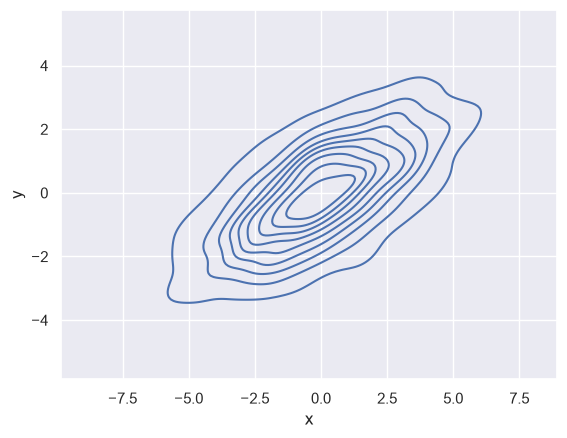

In [19]:
sns.kdeplot(data=data, x="x", y="y");

### New look: Joint Distribution plot

Use:

```python
sns.jointplot(data=data, x='x', y='y', kind='kde', fill=True);
```

This plots the **joint distribution** (the 2D density in the center) and the **marginal distributions** (each variable's 1D density along the top and right side) together in one figure.

Notes:
- `x='x', y='y'` tells it which columns to use (change these if your columns have different names, like `'sepal_length'` and `'sepal_width'`).
- `kind='kde'` makes it a smooth density plot instead of a scatter plot.
- `fill=True` shades the density, replacing the old `shade=True`.

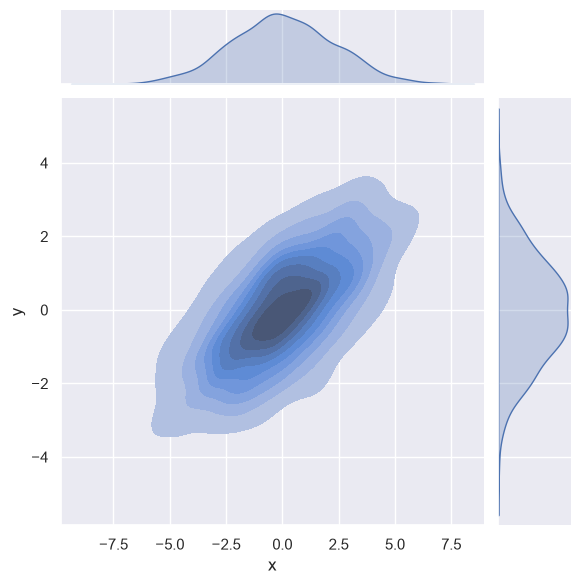

In [22]:
sns.jointplot(data=data, x='x', y='y', kind='kde', fill=True);

### Pair Plots

When you generalize joint plots to datasets of larger dimensions, you end up with *pair plots*. These are very useful for exploring correlations between multidimensional data, when you'd like to plot all pairs of values against each other.

We'll demo this with the well-known Iris dataset, which lists measurements of petals and sepals of three Iris species:

In [23]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


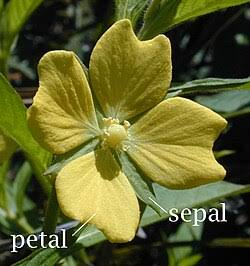

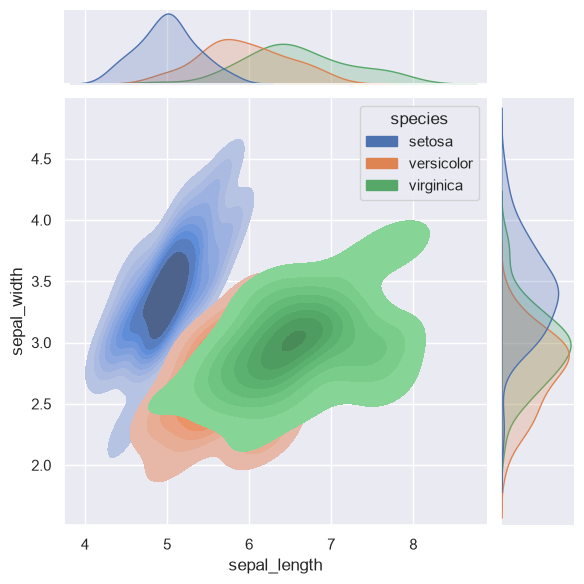

In [25]:
# Visualize the relationship between sepal length and sepal width
sns.jointplot(data=iris, x="sepal_length", y="sepal_width", hue="species", kind="kde", fill=True);

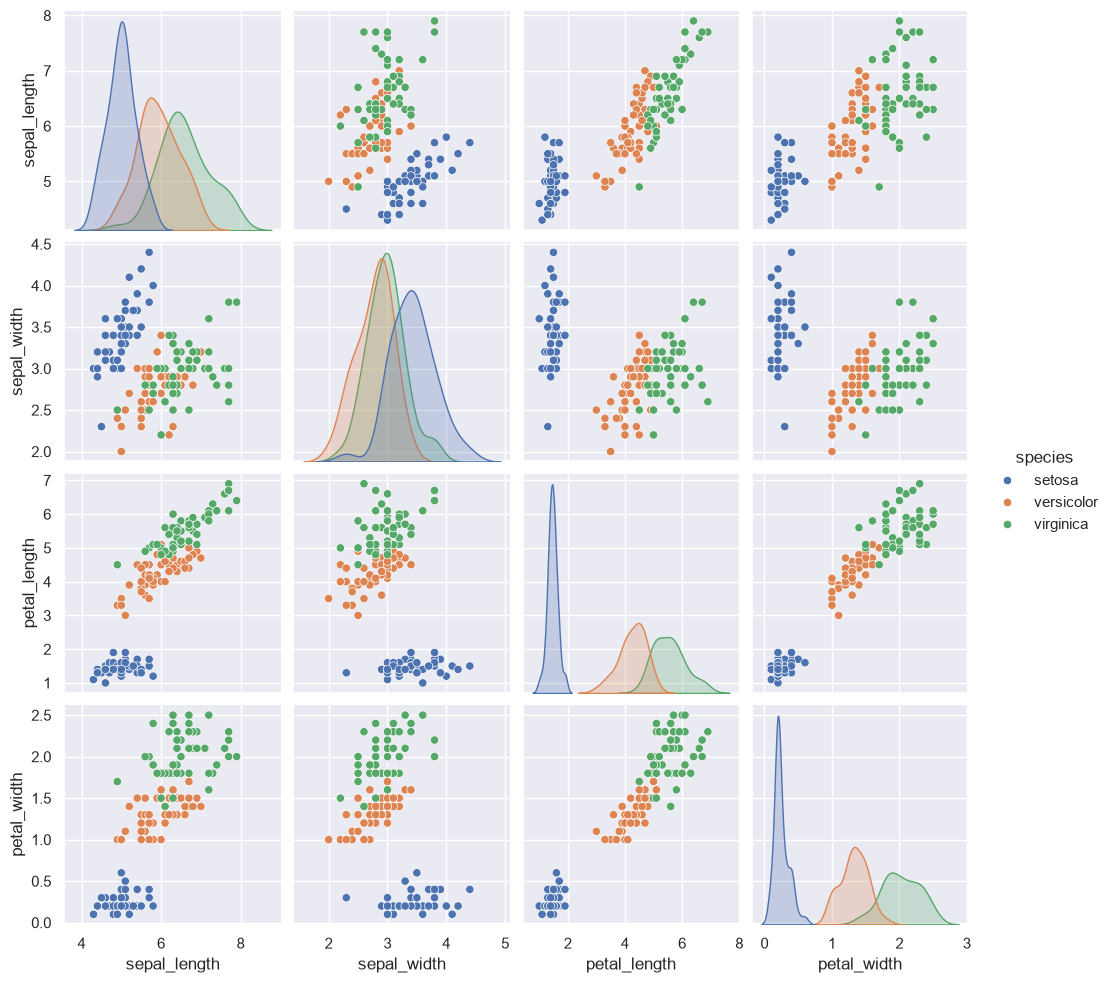

In [26]:
# Visualize the pairwise relationships in the iris dataset
sns.pairplot(iris, hue="species", height=2.5);

## The Tips Dataset Visualization

In [97]:
# Load the "tips" dataset from seaborn
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [98]:
# Create a new column in the tips dataset that calculates the tip percentage
tips["tip_pct"] = 100 * tips["tip"] / tips["total_bill"]

In [99]:
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [100]:
tips["tip_pct"]

0       5.944673
1      16.054159
2      16.658734
3      13.978041
4      14.680765
         ...    
239    20.392697
240     7.358352
241     8.822232
242     9.820426
243    15.974441
Name: tip_pct, Length: 244, dtype: float64

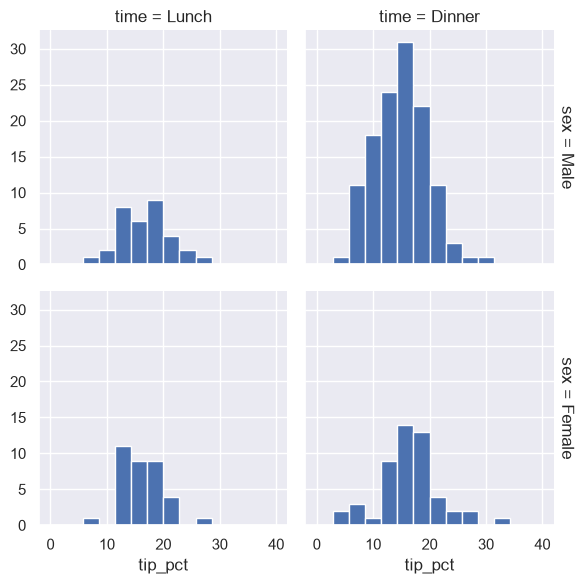

In [101]:
# Create a FacetGrid to visualize the distribution of tip percentages by sex and time
grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));

### Categorical Plots

In [115]:
# g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
# g.set_axis_labels("Day", "Total Bill");

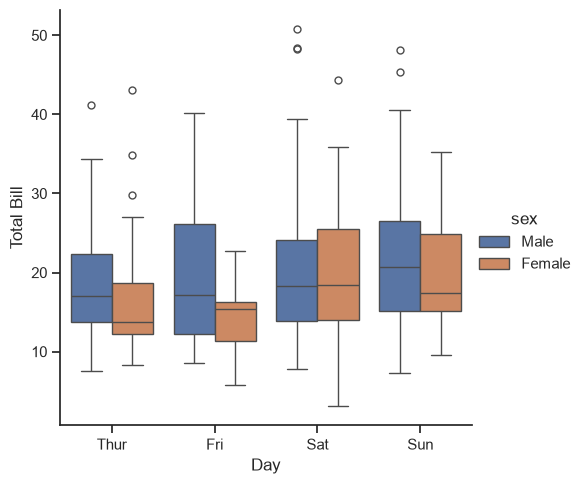

In [116]:
with sns.axes_style(style="ticks"):
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill")

### Joint Distribution

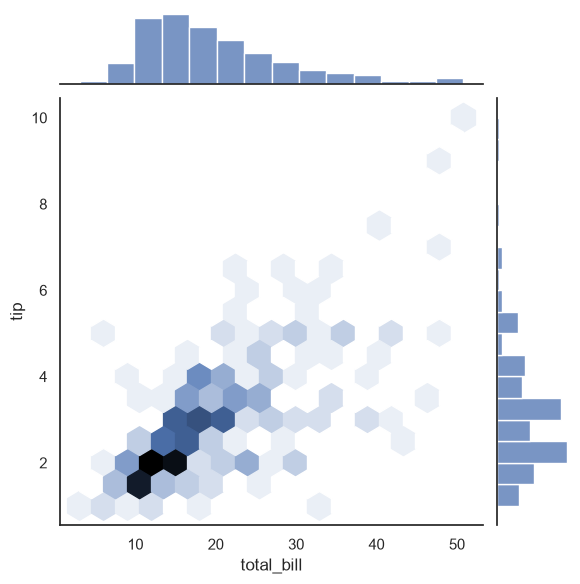

In [117]:
with sns.axes_style("white"):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind="hex")

### Kernel Density Estimation and Regression added

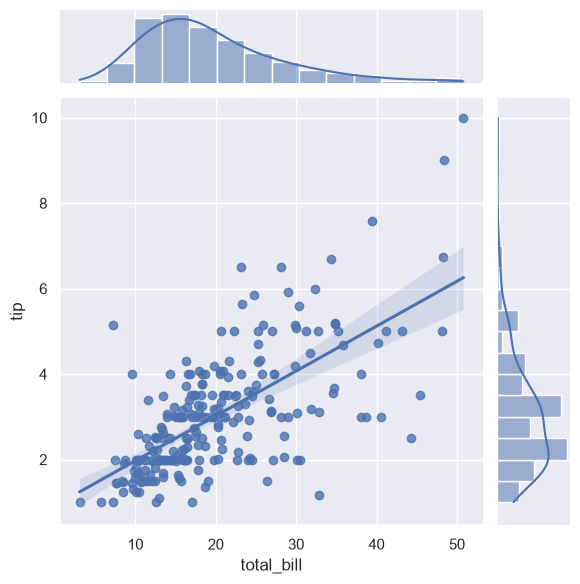

In [118]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg");

## Counting the number of planets

In [119]:
planets = sns.load_dataset("planets")
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [120]:
# planets?

In [121]:
planets.shape

(1035, 6)

In [122]:
# g = sns.catplot(x="year", data=planets, aspect=2, kind="count", color="steelblue")
# g.set_xticklabels(step=5);

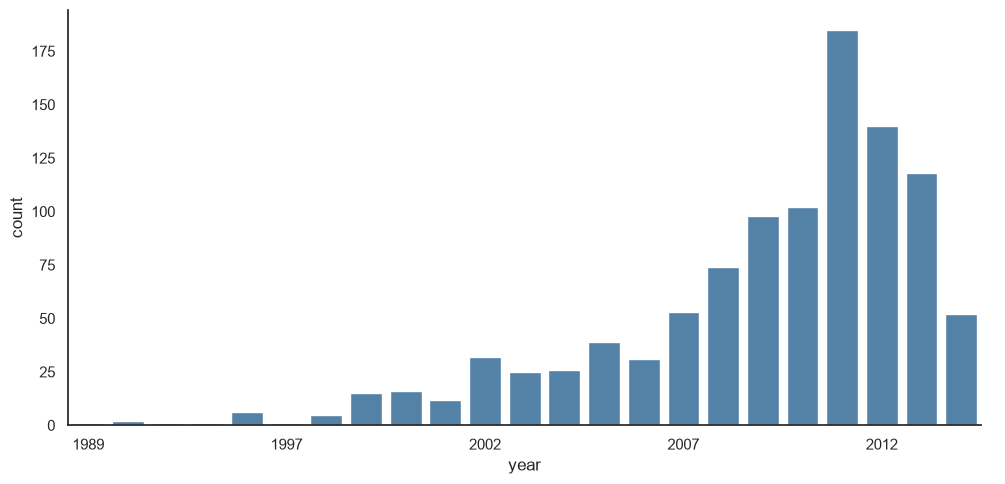

In [123]:
with sns.axes_style("white"):
    g = sns.catplot(x="year", data=planets, aspect=2, kind="count", color="steelblue")
    g.set_xticklabels(step=5)

### Looking into the methods of discovery

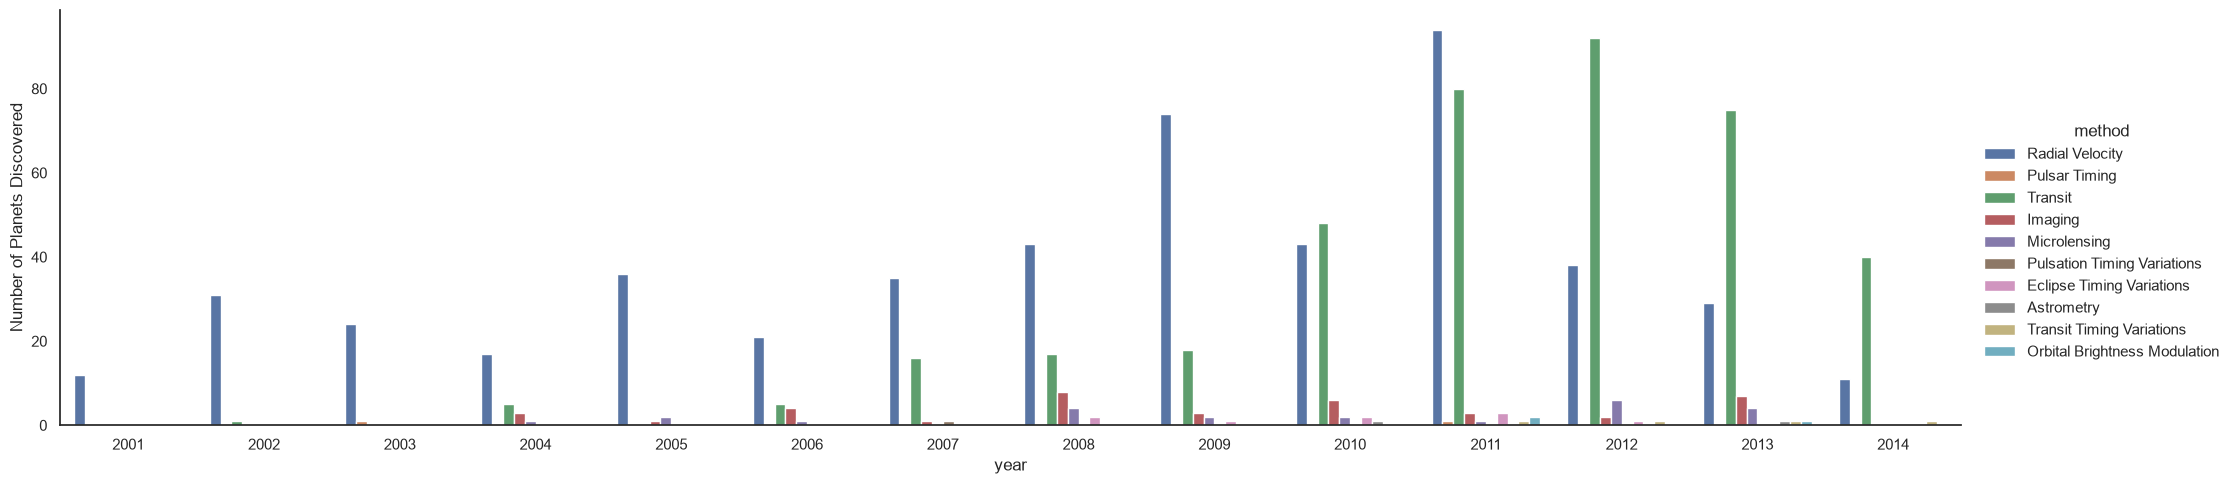

In [124]:
with sns.axes_style("white"):
    g = sns.catplot(
        x="year",
        data=planets,
        aspect=4.0,
        kind="count",
        hue="method",
        order=range(2001, 2015),
    )
    g.set_ylabels("Number of Planets Discovered")

## Marathon Finishing Time Data Analysis

### Download datasets

In [147]:
# Create the 'data' directory if it doesn't exist
import os
if not os.path.exists('data'):
    os.makedirs('data')

# Download the marathon dataset from GitHub and save it in the 'data' directory
url = ('https://raw.githubusercontent.com/jakevdp/'
       'marathon-data/master/marathon-data.csv')
!cd data && curl -O {url}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  836k  100  836k    0     0   319k      0  0:00:02  0:00:02 --:--:--  319k 13  111k    0     0  74051      0  0:00:11  0:00:01  0:00:10 74038


In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load datasets
data = pd.read_csv("data/marathon-data.csv")
data.head()

,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


### The split (time) and final (time) are the str (need to convert)

In [149]:
data.dtypes

age       int64
gender      str
split       str
final       str
dtype: object

In [150]:
import datetime

def convert_time(s):
    h, m, s = map(int, s.split(":"))
    return datetime.timedelta(hours=h, minutes=m, seconds=s)

data = pd.read_csv(
    "data/marathon-data.csv", converters={"split": convert_time, "final": convert_time}
)
data.head()

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59


That will make it easier to manipulate the temporal data. For the purpose of our Seaborn plotting utilities, let's next add columns that give the times in seconds:

### Converted into Micro seconds (us), ensure you avoid the errors

In [151]:
data.dtypes

age                 int64
gender                str
split     timedelta64[us]
final     timedelta64[us]
dtype: object

In [152]:
data["split_sec"] = data["split"].astype("int64") / 1e6
data["final_sec"] = data["final"].astype("int64") / 1e6
data.head()

,age,gender,split,final,split_sec,final_sec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0


## Guide of hours --> seconds: 3938 seconds **is** 1:05:38

Let's do the math:

```
3938 seconds ÷ 60  = 65.63 minutes
65.63 minutes      = 65 min + 0.63 × 60 s
                   = 65 min 38 s
                   = 1 hour 5 min 38 s  ✓
```

That's exactly the `split` value `0 days 01:05:38`.

## Sanity check the range:

| Race event | Typical time | In seconds |
|-----------|--------------|-----------|
| Half marathon split (elite-ish) | ~1:05 | ~3900 |
| Full marathon finish | ~2:09 | ~7700 |
| Sub-2-hour marathon (world record pace) | 2:00:00 | 7200 |
| 4-hour marathon | 4:00:00 | 14400 |

Your `split_sec` ≈ 3900–4000 and `final_sec` ≈ 7700–8000 are **exactly right** for a marathon runner:

- Split at ~1h05m → 3938 s ✓
- Finish at ~2h09m → 7731 s ✓
- `final ≈ 2 × split` → consistent pacing ✓

### Quick rule of thumb
- Seconds in an hour = 3600
- So anything in the 3000s = "just over an hour"
- 7000s = "just under 2 hours"
- 14000s = "just under 4 hours"

Those are **seconds**, spanning roughly 1h06m to 4h26m for the split, and 2h13m to 8h53m for the finish — a sensible range for a marathon field. So 3938 s sits right where it should.

**Bottom line:** 3938 is not "only 3000+" — it's a full **1 hour 5 minutes 38 seconds**. The conversion is correct.

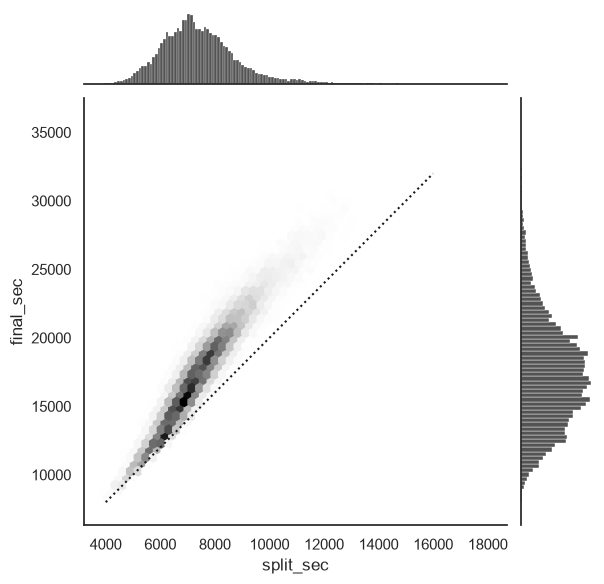

In [153]:
with sns.axes_style("white"):
    g = sns.jointplot(
        data=data, x="split_sec", y="final_sec", kind="hex", color="k"
    )
    g.ax_joint.plot(np.linspace(4000, 16000), np.linspace(8000, 32000), ":k")
plt.show()

In [154]:
data["split_frac"] = 1 - 2 * data["split_sec"] / data["final_sec"]
data.head()

,age,gender,split,final,split_sec,final_sec,split_frac
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842


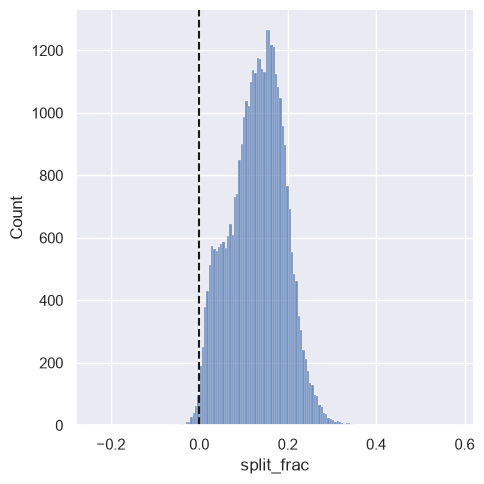

In [155]:
sns.displot(data["split_frac"], kde=False)
plt.axvline(0, color="k", linestyle="--");

In [156]:
sum(data.split_frac < 0)

251

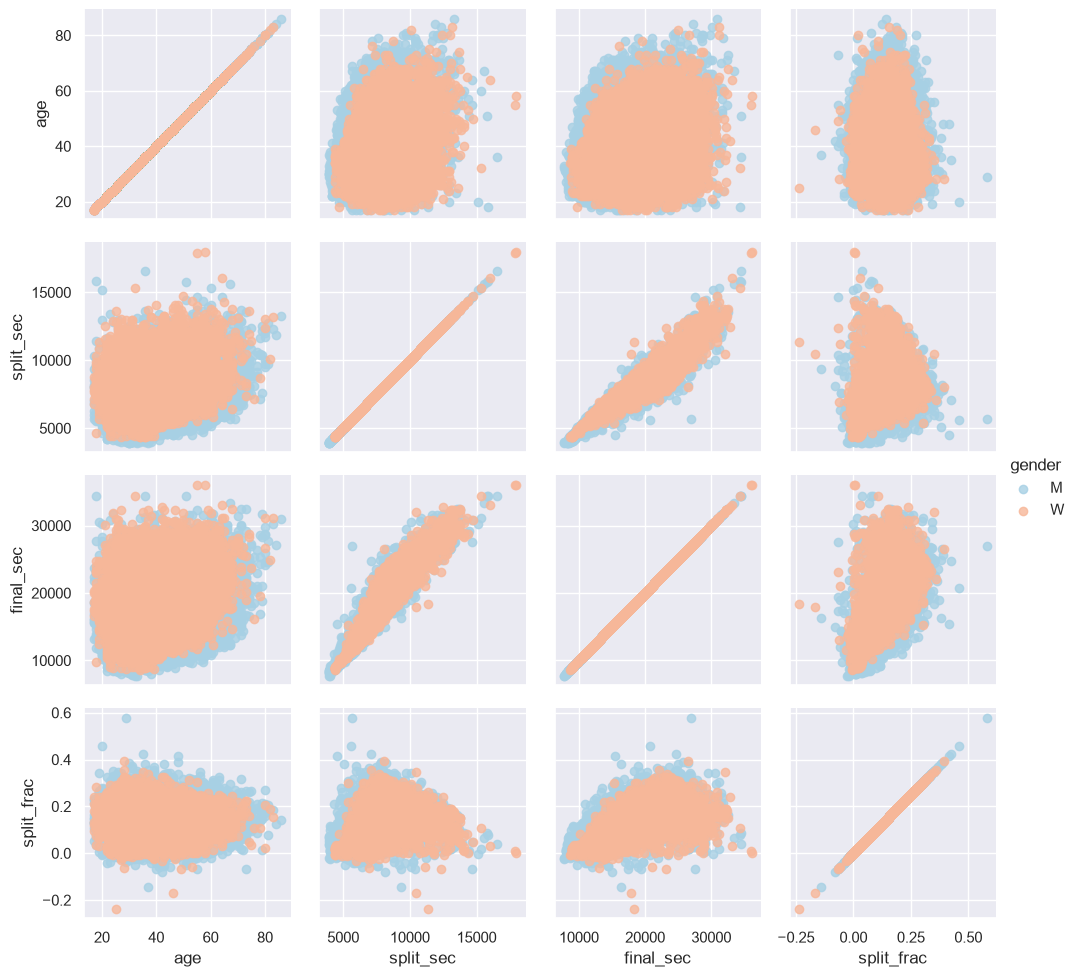

In [157]:
g = sns.PairGrid(
    data,
    vars=["age", "split_sec", "final_sec", "split_frac"],
    hue="gender",
    palette="RdBu_r",
)
g.map(plt.scatter, alpha=0.8)
g.add_legend();

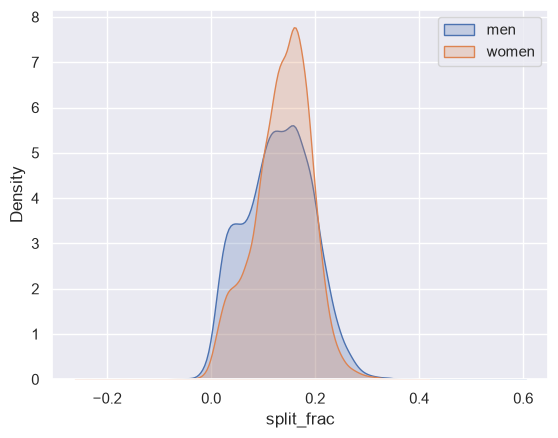

In [158]:
sns.kdeplot(x=data.split_frac[data.gender == "M"], label="men", fill=True)
sns.kdeplot(x=data.split_frac[data.gender == "W"], label="women", fill=True)
plt.xlabel("split_frac")
plt.legend()
plt.show()

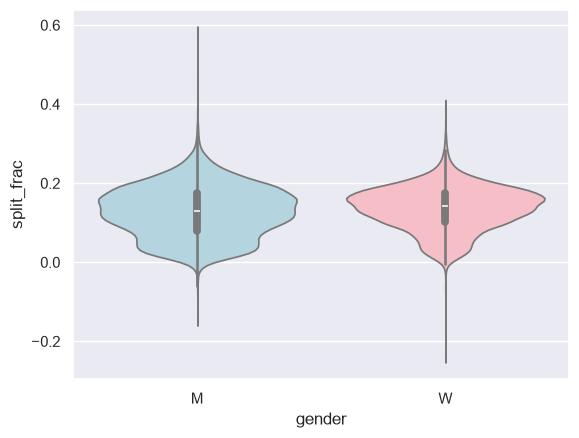

In [159]:
sns.violinplot(
    data=data,
    x="gender",
    y="split_frac",
    hue="gender",
    palette=["lightblue", "lightpink"],
    legend=False,
)
plt.show()

In [160]:
data["age_dec"] = data.age.map(lambda age: 10 * (age // 10))
data.head()

,age,gender,split,final,split_sec,final_sec,split_frac,age_dec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756,30
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262,30
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443,30
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097,30
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842,30


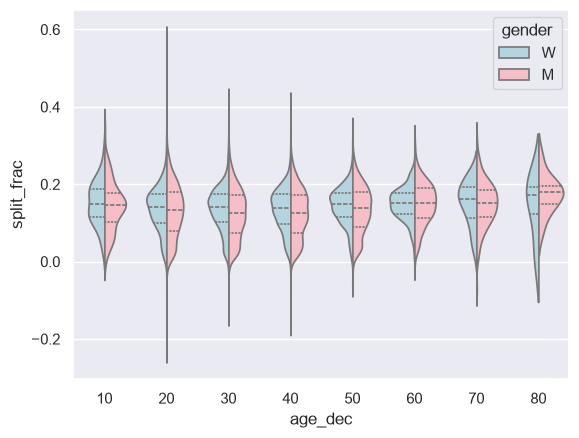

In [161]:
men = data.gender == "M"
women = data.gender == "W"

with sns.axes_style(style=None):
    sns.violinplot(
        x="age_dec",
        y="split_frac",
        hue="gender",
        data=data,
        split=True,
        inner="quartile",
        palette=["lightblue", "lightpink"],
    )

In [162]:
(data.age > 80).sum()

np.int64(7)

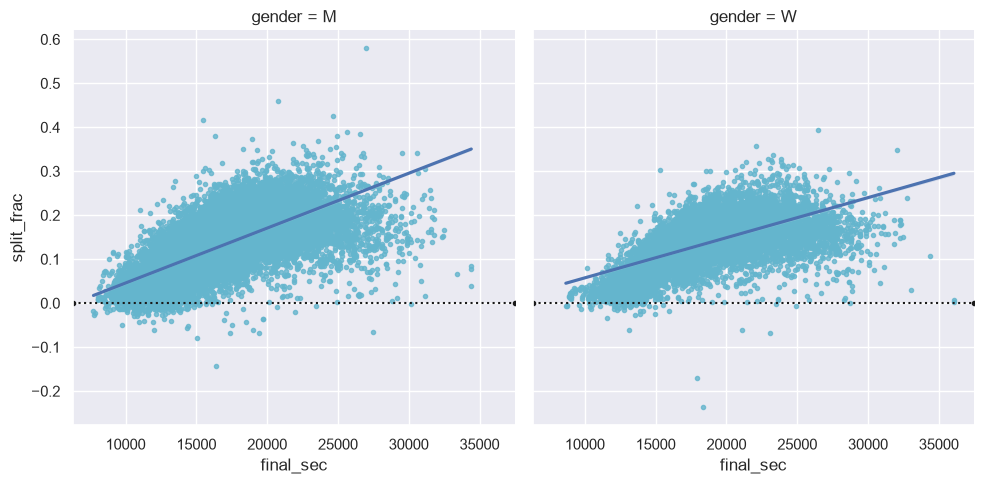

In [163]:
g = sns.lmplot(
    x="final_sec",
    y="split_frac",
    col="gender",
    data=data,
    markers=".",
    scatter_kws=dict(color="c"),
)
g.map(plt.axhline, y=0.0, color="k", ls=":");